In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [6]:
# Load Iris dataset using sklearn.
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

In [7]:
# Selecting only two features for visualization
X = df[['sepal length (cm)', 'sepal width (cm)']].values

In [8]:
#Standardize the data
Scaler = StandardScaler()
X_scaled = Scaler.fit_transform(X)

In [9]:
Kmeans = KMeans(n_clusters=5, init='k-means++',random_state=42)
y_kmeans = Kmeans.fit_predict(X_scaled)

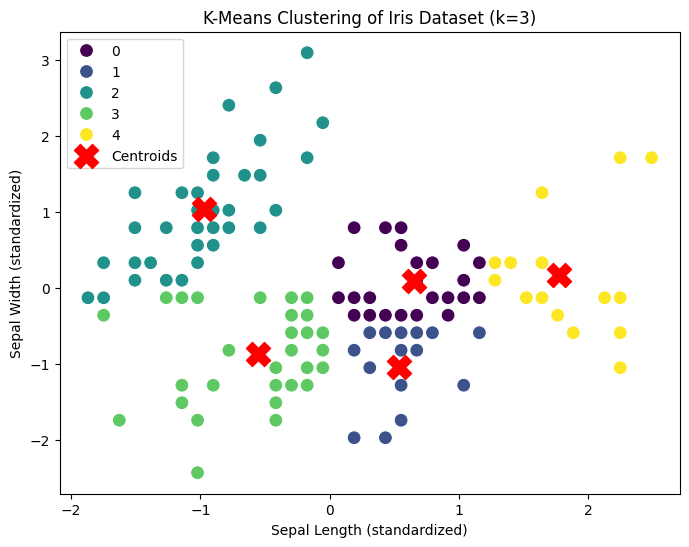

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_scaled[:,0],y=X_scaled[:,1],hue=y_kmeans,palette='viridis',s=100)
plt.scatter(Kmeans.cluster_centers_[:, 0],Kmeans.cluster_centers_[:, 1],s=300,c='red',marker='X',label='Centroids')
plt.xlabel('Sepal Length (standardized)')
plt.ylabel('Sepal Width (standardized)')
plt.title('K-Means Clustering of Iris Dataset (k=3)')
plt.legend()
plt.show()

# Exercise 2:

In [11]:
wcss = []
k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

In [12]:
pip install kneed

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from kneed import KneeLocator
knee_locator = KneeLocator(k_values, wcss, curve='convex', direction='decreasing')
optimal_k = knee_locator.elbow

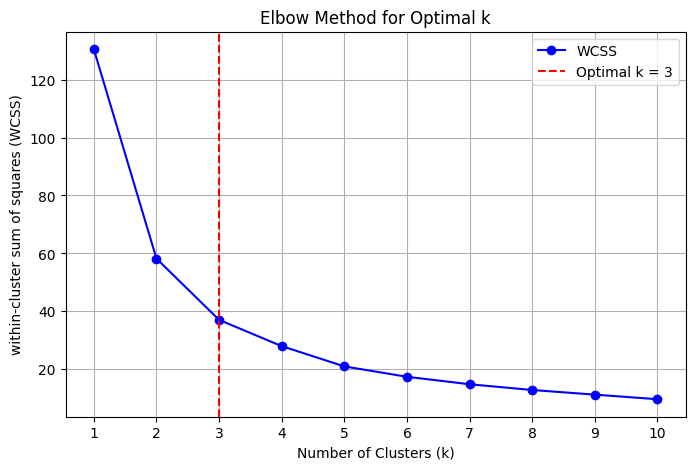

In [24]:
plt.figure(figsize=(8,5))
plt.plot(k_values, wcss, marker='o',linestyle='-',color='b',label='WCSS')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k = {optimal_k}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel("within-cluster sum of squares (WCSS)")
plt.title('Elbow Method for Optimal k')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

# Exercise 3: Implement PCA on a given matrix

In [15]:
import numpy as np

In [ ]:
# step1: create a sample dataset
X=np.array([
    [2,3,4],
    [3,5,6],
    [5,8,9],
    [6,9,11],
    [7,10,13]
])

In [20]:
# step2: compute mean value for each column
mean_X = np.mean(X, axis=0)
print(mean_X)

[4.6 7.  8.6]


In [21]:
# step3: center the data
X_centered=X - mean_X
print(X_centered)

[[-2.6 -4.  -4.6]
 [-1.6 -2.  -2.6]
 [ 0.4  1.   0.4]
 [ 1.4  2.   2.4]
 [ 2.4  3.   4.4]]


In [23]:
# step4: compute the covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)
print(cov_matrix)

[[ 4.3   6.    7.55]
 [ 6.    8.5  10.5 ]
 [ 7.55 10.5  13.3 ]]


In [ ]:
# Step5: compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print(eigenvalues)

[2.59637803e+01 5.52557327e-03 1.30694106e-01]


In [26]:
print(eigenvectors)

[[ 0.4066816   0.90812885  0.09955937]
 [ 0.56930735 -0.16669075 -0.80504865]
 [ 0.71449228 -0.38407836  0.58479449]]


In [ ]:
#step6: sort eigenvalues and eigenvectors
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

In [32]:
# step7: project the data onto the principal components
X_transformed_1 = X_centered @ sorted_eigenvectors[:, 0]

In [ ]:
#3 to 2 (Project onto first 2 principal components)
X_transformed_2 = X_centered @ sorted_eigenvectors[:, :2]

In [ ]:
#output the transformed data

print("Transformed Data (3 to 1):")
print(X_transformed_1)
print("\nTransformed Data (3 to 2):")
print(X_transformed_2)

Transformed Data (3 to 1):
[-6.62126605 -3.64698519  1.0177769   3.42275041  5.82772392]

Transformed Data (3 to 2):
[[-6.62126605  0.27128556]
 [-3.64698519 -0.06966338]
 [ 1.0177769  -0.5313071 ]
 [ 3.42275041 -0.0672074 ]
 [ 5.82772392  0.39689231]]


# principal Component Analysis

In [ ]:
#import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [39]:
# load dataset
df = pd.read_csv("datasets/winequality-red.csv")


In [40]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [41]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1596 entries, 0 to 1595
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1596 non-null   float64
 1   volatile acidity      1596 non-null   float64
 2   citric acid           1596 non-null   float64
 3   residual sugar        1596 non-null   float64
 4   chlorides             1596 non-null   float64
 5   free sulfur dioxide   1596 non-null   float64
 6   total sulfur dioxide  1596 non-null   float64
 7   density               1596 non-null   float64
 8   pH                    1596 non-null   float64
 9   sulphates             1596 non-null   float64
 10  alcohol               1596 non-null   float64
 11  quality               1596 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 149.8 KB


In [43]:
df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [44]:
X=df.iloc[:,:-1].values
y=df.iloc[:,-1].values

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
#feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [50]:
#Apply PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=7)
X_train = pca.fit_transform(X_train)

In [49]:
X_test = pca.transform(X_test)

In [51]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(random_state=0)
model.fit(X_train,y_train)

c:\Users\M M\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [52]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred=model.predict(X_test)

In [55]:
matrix = confusion_matrix(y_test,y_pred)
print(matrix)


[[ 0  0  1  0  0  0]
 [ 0  0  6  4  0  0]
 [ 0  0 94 36  1  0]
 [ 0  0 51 84  8  0]
 [ 0  0  3 26  5  0]
 [ 0  0  0  1  0  0]]


In [56]:
print("Accuracy:", accuracy_score(y_test,y_pred) * 100 )

Accuracy: 57.1875


In [57]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.61      0.72      0.66       131
           6       0.56      0.59      0.57       143
           7       0.36      0.15      0.21        34
           8       0.00      0.00      0.00         1

    accuracy                           0.57       320
   macro avg       0.25      0.24      0.24       320
weighted avg       0.53      0.57      0.55       320



c:\Users\M M\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\M M\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\M M\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [1]:
pip install pyclustering

     ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
     ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
     ---- ----------------------------------- 0.3/2.6 MB ? eta -:--:--
     ------------ --------------------------- 0.8/2.6 MB 2.7 MB/s eta 0:00:01
     -------------------- ------------------- 1.3/2.6 MB 2.5 MB/s eta 0:00:01
     -------------------- ------------------- 1.3/2.6 MB 2.5 MB/s eta 0:00:01
     -------------------- ------------------- 1.3/2.6 MB 2.5 MB/s eta 0:00:01
     ---------------------------- ----------- 1.8/2.6 MB 1.5 MB/s eta 0:00:01
     ---------------------------- ----------- 1.8/2.6 MB 1.5 MB/s eta 0:00:01
     ------------------------------------ --- 2.4/2.6 MB 1.4 MB/s eta 0:00:01
     ---------------------------------------- 2.6/2.6 MB 1.3 MB/s  0:00:02
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting require


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.utils import distance_metric, type_metric
from sklearn import datasets
from sklearn.preprocessing import StandardScaler


In [5]:
# load the iris dataset
wine = datasets.load_wine()

In [6]:
# convert the data into a pandas dataframe for better readbility
wine_df = pd.DataFrame(data=wine.data, columns=wine.feature_names)

In [11]:
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
#Standardize the datasets
scaler = StandardScaler()
X_scaled = scaler.fit_transform(wine_df)#data

In [ ]:
# intial medoids(can be randomly chosen or specified )
intial_medoids = [0, 1, 2]

In [13]:
import random
intial_medoids = random.sample(range(len(X_scaled)), 3)

In [16]:
#create k-medoids instance 
metric = distance_metric(type_metric.EUCLIDEAN)
#Euclidean distance
kmedoids_instance = kmedoids(X_scaled, intial_medoids, metric=metric)

In [17]:
# Perform the clustering 
kmedoids_instance.process()

In [18]:
# get the resulting clusters and medoids
clusters = kmedoids_instance.get_clusters()
method = kmedoids_instance.get_medoids()

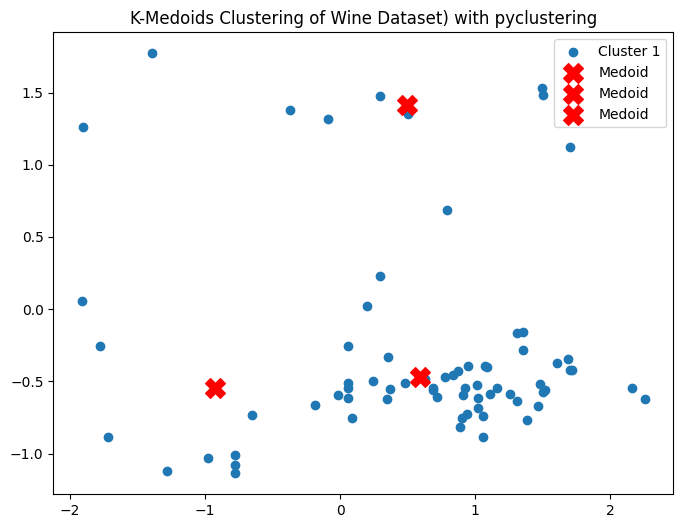

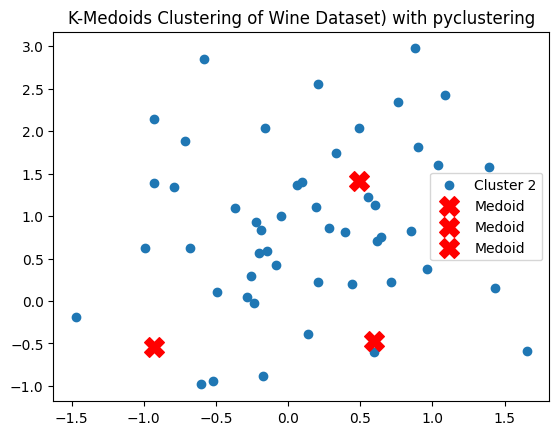

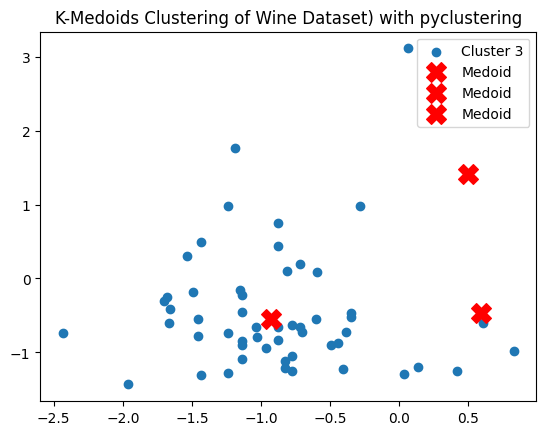

In [ ]:
# plot the results
plt.figure(figsize=(8,6))
for cluster in clusters:
    plt.scatter(X_scaled[cluster, 0], X_scaled[cluster, 1], label=f'Cluster {clusters.index(cluster)+1}')
    
    # Mark the medois in red
    for medoid in method:
        plt.scatter(X_scaled[medoid, 0], X_scaled[medoid, 1], s=200, c='red', marker='X', label='Medoid' )
        
    plt.title("K-Medoids Clustering of Wine Dataset) with pyclustering")
    plt.legend()
    plt.show()
    